# 의료시설 데이터 필터링 및 포인트 지도화

건강보험심사평가원(HIRA) 「전국 병의원 및 약국 현황(2026.6)」의 `1.병원정보서비스` 파일에서 다음 7개 종별만 필터링하여 포인트 shapefile로 변환한다.

`병원 · 의원 · 종합병원 · 보건소 · 보건지소 · 보건의료원 · 보건진료소`

**참고**: 원본 파일에 `좌표(X)`(경도) · `좌표(Y)`(위도) 컬럼이 이미 포함되어 있어(WGS84), 별도의 주소 지오코딩 없이 바로 좌표를 사용한다.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"  # 한글 라벨 표시를 위한 폰트 설정
plt.rcParams["axes.unicode_minus"] = False

## 1. 원본 데이터 로드

HIRA 병원정보서비스 원본(전국 79,772개 요양기관)을 불러온다.

In [2]:
raw = pd.read_excel("data/raw_hira_hospital_info/1.병원정보서비스(2026.6.).xlsx")
print(f"전체 요양기관: {len(raw)}개")
raw["종별코드명"].value_counts()

전체 요양기관: 79772개


종별코드명
의원       37800
치과의원     19388
한의원      14885
보건진료소     1898
병원        1429
보건지소      1288
요양병원      1287
한방병원       623
종합병원       337
정신병원       261
치과병원       248
보건소        248
상급종합        47
조산원         17
보건의료원       16
Name: count, dtype: int64

## 2. 대상 종별 필터링

병원·의원·종합병원·보건소·보건지소·보건의료원·보건진료소 7개 종별만 남긴다.
(상급종합병원, 요양병원, 정신병원, 치과병원/의원, 한방병원/한의원, 조산원, 약국은 제외)

In [3]:
TARGET_TYPES = ["병원", "의원", "종합병원", "보건소", "보건지소", "보건의료원", "보건진료소"]

filtered = raw[raw["종별코드명"].isin(TARGET_TYPES)].copy()
print(f"필터링 후: {len(filtered)}개")
filtered["종별코드명"].value_counts()

필터링 후: 43016개


종별코드명
의원       37800
보건진료소     1898
병원        1429
보건지소      1288
종합병원       337
보건소        248
보건의료원       16
Name: count, dtype: int64

## 3. 좌표 결측 확인 및 포인트 GeoDataFrame 생성

`좌표(X)`(경도)·`좌표(Y)`(위도)가 없는 행은 제외한다 (전체 대비 극소수).

In [4]:
n_before = len(filtered)
filtered = filtered.dropna(subset=["좌표(X)", "좌표(Y)"]).copy()
print(f"좌표 결측으로 제외: {n_before - len(filtered)}개 (필터링 후 {len(filtered)}개 유지)")

# DBF 필드명은 최대 10바이트(한글 5자)라 한글 컬럼명은 잘리거나 깨질 수 있어 영문 약어로 변경
facilities = gpd.GeoDataFrame(
    filtered[["요양기관명", "종별코드명", "시도코드명", "시군구코드명", "주소"]].rename(columns={
        "요양기관명": "FAC_NM",
        "종별코드명": "FAC_TYPE",
        "시도코드명": "SIDO_NM",
        "시군구코드명": "SGG_NM",
        "주소": "ADDR",
    }),
    geometry=gpd.points_from_xy(filtered["좌표(X)"], filtered["좌표(Y)"]),
    crs="EPSG:4326",
)
facilities["lon"] = filtered["좌표(X)"].values
facilities["lat"] = filtered["좌표(Y)"].values
facilities.head()

좌표 결측으로 제외: 2개 (필터링 후 43014개 유지)


,FAC_NM,FAC_TYPE,SIDO_NM,SGG_NM,ADDR,geometry,lon,lat
0,(VOM)봄안과의원,의원,대구,대구동구,"대구광역시 동구 안심로 58, 3층 (율하동, 율하메디빌)",POINT (128.69189 35.86985),128.691894,35.869852
2,(사) 경찰공제회 포항의원,의원,경북,포항남구,"경상북도 포항시 남구 오천읍 냉천로 656, (오천읍)",POINT (129.3929 35.94226),129.392899,35.942257
3,(사)경찰공제회 강서적성의원,의원,서울,강서구,"서울특별시 강서구 남부순환로 171, 강서운전면허시험장만남의광장 적성검사소호 (외발산동)",POINT (126.82198 37.5495),126.821985,37.549498
4,(사)경찰공제회남부의원,의원,인천,인천남동구,"인천광역시 남동구 아암대로 1247, (고잔동)",POINT (126.70886 37.38491),126.708861,37.384910
5,(사)대한산업보건협회 남부산의원,의원,부산,부산강서구,"부산광역시 강서구 명지국제6로1번길 30, A동 3층 (명지동)",POINT (128.90015 35.0947),128.900150,35.094700


## 4. 포인트 shapefile 저장

분석에 쓰인 500m/100m 격자와 좌표계를 맞추기 위해 EPSG:5179로 변환하고, 원본 위경도(`lon`/`lat`)는 참고용으로 함께 남겨둔다.

필드 폭을 명시적으로 지정해 dbf 파일이 불필요하게 커지지 않도록 한다 (한글 문자열 컬럼은 저장 시 폭이 과도하게 넓게 잡히는 경우가 있음).

In [5]:
facilities_5179 = facilities.to_crs("EPSG:5179")

schema = {
    "geometry": "Point",
    "properties": {
        "FAC_NM": "str:40",
        "FAC_TYPE": "str:10",
        "SIDO_NM": "str:10",
        "SGG_NM": "str:20",
        "ADDR": "str:125",
        "lon": "float",
        "lat": "float",
    },
}

out_dir = "data/medical_facilities_filtered"
import os
os.makedirs(out_dir, exist_ok=True)
out_path = f"{out_dir}/medical_facilities_filtered.shp"
facilities_5179.to_file(out_path, encoding="cp949", schema=schema, engine="fiona")
print("저장 완료:", out_path)

저장 완료: data/medical_facilities_filtered/medical_facilities_filtered.shp


## 5. 시각화

전국 분포와, 연구 대상 지역(대구·경북 10개 시·군·구)에 겹쳐진 분포를 함께 확인한다.

In [6]:
sigungu = gpd.read_file("data/BND_SIGUNGU_PG/BND_SIGUNGU_PG.shp", encoding="cp949")

target_codes = [
    "22010", "22020", "22030", "22040", "22050", "22060", "22070", "22510", "22520",  # 대구
    "37050", "37030", "37070", "37100",  # 구미, 김천, 영천, 경산
    "37560", "37570", "37580", "37590",  # 청도, 고령, 성주, 칠곡
]
target_sigungu = sigungu[sigungu["SIGUNGU_CD"].isin(target_codes)].copy()
target_sigungu_5179 = target_sigungu.to_crs(facilities_5179.crs)
print(f"대상 시군구: {len(target_sigungu_5179)}개 폴리곤")

대상 시군구: 17개 폴리곤


/var/folders/fs/5wfxwz6j2slbp92s10056ygr0000gn/T/ipykernel_92363/1250642599.py:18: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  sub.plot(ax=axes[1], markersize=8, color=color, label=t, zorder=2)


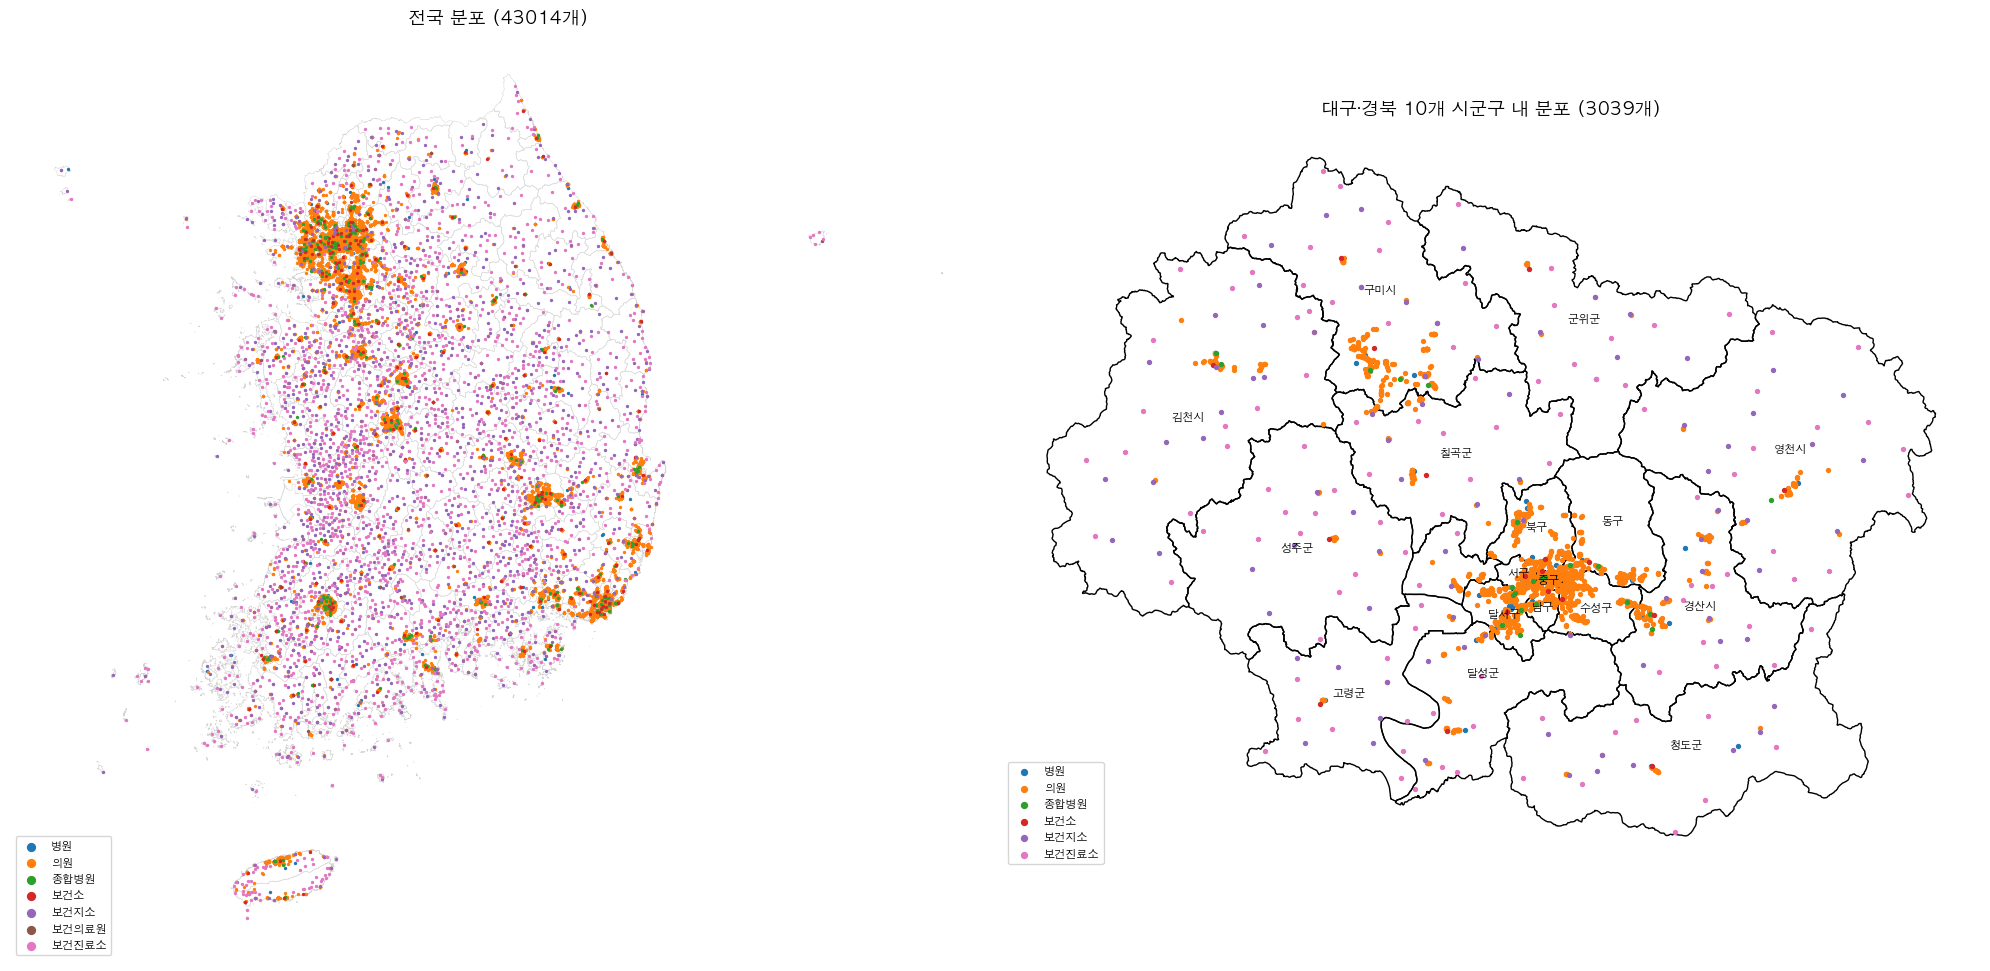

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# (좌) 전국 분포
sigungu.to_crs(facilities_5179.crs).boundary.plot(ax=axes[0], color="lightgray", linewidth=0.3, zorder=1)
for t, color in zip(TARGET_TYPES, plt.cm.tab10.colors):
    sub = facilities_5179[facilities_5179["FAC_TYPE"] == t]
    sub.plot(ax=axes[0], markersize=2, color=color, label=t, zorder=2)
axes[0].set_title(f"전국 분포 ({len(facilities_5179)}개)", fontsize=13)
axes[0].set_axis_off()
axes[0].legend(markerscale=4, fontsize=8, loc="lower left")

# (우) 대구·경북 10개 시군구 확대
target_sigungu_5179.boundary.plot(ax=axes[1], color="black", linewidth=1.0, zorder=1)
facilities_in_target = gpd.sjoin(facilities_5179, target_sigungu_5179[["SIGUNGU_NM", "geometry"]],
                                  how="inner", predicate="within")
for t, color in zip(TARGET_TYPES, plt.cm.tab10.colors):
    sub = facilities_in_target[facilities_in_target["FAC_TYPE"] == t]
    sub.plot(ax=axes[1], markersize=8, color=color, label=t, zorder=2)
for _, row in target_sigungu_5179.iterrows():
    c = row.geometry.centroid
    axes[1].annotate(row["SIGUNGU_NM"], xy=(c.x, c.y), ha="center", va="center",
                      fontsize=8, fontweight="bold", zorder=3)
axes[1].set_title(f"대구·경북 10개 시군구 내 분포 ({len(facilities_in_target)}개)", fontsize=13)
axes[1].set_axis_off()
axes[1].legend(markerscale=1.5, fontsize=8, loc="lower left")

plt.tight_layout()
plt.savefig("data/medical_facilities_filtered/medical_facilities_visualization.png", dpi=200)
plt.show()

In [8]:
facilities_in_target["FAC_TYPE"].value_counts()

FAC_TYPE
의원       2694
보건진료소     112
병원        107
보건지소       86
종합병원       22
보건소        18
Name: count, dtype: int64